## 1.Preprocessing/data cleaning

In [1]:
#importing all the required libraries 
import psycopg2
from sqlalchemy import create_engine, Column, Integer, String
from sqlalchemy.ext.declarative import declarative_base
from sqlalchemy.orm import sessionmaker
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [2]:
# defining again the database parameters
db_params = {
    'host': '194.171.191.226',
    'port': '6379',
    'database': 'postgres',
    'user': 'group2',
    'password': 'blockd_2024group2_58'
}
 
# creating a connection string
conn_string = f"postgresql+psycopg2://{db_params['user']}:{db_params['password']}@{db_params['host']}:{db_params['port']}/{db_params['database']}"
 
# creating an SQLAlchemy engine
engine = create_engine(conn_string)
 
# pandas to execute a query and load data into a DataFrame
query = "SELECT * FROM data_lake.safe_driving"
df_safe_driving = pd.read_sql(query, engine)
 
# clsoing the connection
engine.dispose()
 
# ensuing 'event_start' and 'event_end' are in datetime format
df_safe_driving['event_start'] = pd.to_datetime(df_safe_driving['event_start'])
df_safe_driving['event_end'] = pd.to_datetime(df_safe_driving['event_end'])
 
# checking for duplicate values
dup_count = df_safe_driving.duplicated().sum()
print('There are', dup_count, 'duplicate values')
 
# one more chcking for missing values in different forms
missing_count = df_safe_driving.isnull().sum().sum()
print('There are', missing_count, 'missing values')
 
# setting the future option to opt-in to the new behavior
pd.set_option('future.no_silent_downcasting', True)
 
# replcing empty strings with NaN in the 'road_number' column
df_safe_driving['road_number'] = df_safe_driving['road_number'].replace("", np.nan)
 
# verifying that the replacement has been done
missing_values_count = df_safe_driving.isnull().sum()
print("Total missing values per column:")
print(missing_values_count[missing_values_count > 0])
 
# summarizing all findings
total_missing = missing_values_count.sum()
print(f"Total number of missing values (including special values): {total_missing}")
 
# veryfying the rows with missing values
print(df_safe_driving.isna().sum())
 
#start cleaning
print('\nStarting Cleaning:\n')
 
# removing the 'road_number' column
df_safe_driving = df_safe_driving.drop('road_number', axis=1)
 
# veryfying that the rows with missing 'road_number' values have been removed
print(df_safe_driving.isna().sum())
 
# strping whitespace from the 'category' column
df_safe_driving['category'] = df_safe_driving['category'].str.strip()
 
# unique values
print(df_safe_driving['category'].unique())
 
# checking for duplicate values
dup_count = df_safe_driving.duplicated().sum()
print('After cleaning there are', dup_count, 'duplicate values')
 
# checking one more time for missing values in different forms
missing_count = df_safe_driving.isnull().sum().sum()
print('After cleaning there are', missing_count, 'missing values')
 
# initializing LabelEncoder
label_encoder = LabelEncoder()
 
#encoding the 'category' column
df_safe_driving['category_encoded'] = label_encoder.fit_transform(df_safe_driving['category'])
 
# strpping whitespace from the 'category' column
df_safe_driving['incident_severity'] = df_safe_driving['incident_severity'].str.strip()
 
#printing the unique values
print(df_safe_driving['incident_severity'].unique())
 
def classify_incident_severity_corrected(severity):
    low = ['HA1', 'HB1', 'HC1', 'SP1']
    medium = ['HC4', 'HC13', 'HA2', 'HB2', 'HC2', 'HC5', 'HC7', 'HC14', 'HC16', 'SP2', 'SP3']
    high = ['HA3', 'HB3', 'HC3', 'HC9', 'HC11', 'HC12', 'HC15', 'HC17', 'HC18', 'HC19', 'HC20', 'HC21', 'HC6', 'HC8', 'HC10', 'SP4', 'SP5']
    if severity in low:
        return 'Low'
    elif severity in medium:
        return 'Medium'
    elif severity in high:
        return 'High'
    else:
        return 'Unknown'
 
# corrected classification function
df_safe_driving['incident_severity_bin'] = df_safe_driving['incident_severity'].apply(classify_incident_severity_corrected)
 
#updated DataFrame
df_safe_driving.head()

There are 0 duplicate values
There are 0 missing values
Total missing values per column:
road_number    964488
dtype: int64
Total number of missing values (including special values): 964488
eventid                   0
event_start               0
event_end                 0
duration_seconds          0
latitude                  0
longitude                 0
speed_kmh                 0
end_speed_kmh             0
maxwaarde                 0
category                  0
incident_severity         0
is_valid                  0
road_segment_id           0
road_manager_type         0
road_number          964488
road_name                 0
place_name                0
municipality_name         0
road_manager_name         0
dtype: int64

Starting Cleaning:

eventid              0
event_start          0
event_end            0
duration_seconds     0
latitude             0
longitude            0
speed_kmh            0
end_speed_kmh        0
maxwaarde            0
category             0
incident_sever

,eventid,event_start,event_end,duration_seconds,latitude,longitude,speed_kmh,end_speed_kmh,maxwaarde,category,incident_severity,is_valid,road_segment_id,road_manager_type,road_name,place_name,municipality_name,road_manager_name,category_encoded,incident_severity_bin
0,41882896,2020-01-31 16:41:34.000,2020-01-31 16:41:45.000,11.0,51.59169,4.757804,62.764416,64.373760,74.029820,SPEED,SP1,True,600915496,G,Lunetstraat,Breda,Breda,Breda,3,Low
1,41546611,2020-01-31 12:28:44.500,2020-01-31 12:29:06.500,22.0,51.57178,4.776061,64.373760,64.373760,74.029820,SPEED,SP1,True,600383819,G,Graaf Engelbertlaan,Breda,Breda,Breda,3,Low
2,43078754,2020-01-31 15:32:59.300,2020-01-31 15:33:01.900,2.6,51.58178,4.826694,32.186880,30.577536,0.904451,HARSH CORNERING,HC1,True,231198030,G,Franklin Rooseveltlaan,Breda,Breda,Breda,2,Low
3,41901445,2020-01-31 16:39:19.900,2020-01-31 16:39:22.500,2.6,51.58182,4.826675,33.796223,30.577536,0.854562,HARSH CORNERING,HC1,True,231198030,G,Franklin Rooseveltlaan,Breda,Breda,Breda,2,Low
4,42320615,2020-01-31 08:35:38.700,2020-01-31 08:35:42.000,3.3,51.60246,4.710097,27.358849,27.358849,0.854562,HARSH CORNERING,HC1,True,216203041,G,Heikantsestraat,Prinsenbeek,Breda,Breda,2,Low


Random Sampling with Replacement bin counts:
 incident_severity_bin
High      63533
Low       63533
Medium    63533
Name: count, dtype: int64


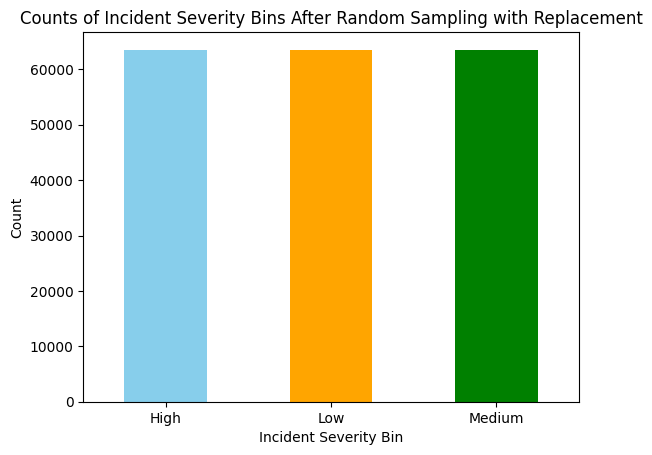

In [3]:
# Random Sampling with Replacement
sampled_dfs = []
for bin_label, group in df_safe_driving.groupby('incident_severity_bin'):
    sampled_dfs.append(group.sample(n=63533, replace=True, random_state=42))
df_sampled_replacement = pd.concat(sampled_dfs)

# count for each incident severity bin in the resampled data
sampled_replacement_bin_counts = df_sampled_replacement['incident_severity_bin'].value_counts()
print("Random Sampling with Replacement bin counts:\n", sampled_replacement_bin_counts)

# resampled dataframe to df_safe_driving
df_safe_driving = df_sampled_replacement

# Plotting the histogram with the balanced bins 
sampled_replacement_bin_counts.plot(kind='bar', color=['skyblue', 'orange', 'green'])
plt.xlabel('Incident Severity Bin')
plt.ylabel('Count')
plt.title('Counts of Incident Severity Bins After Random Sampling with Replacement')
plt.xticks(rotation=0)
plt.show()

### Model 1 - Gradient Boosting without Grid Search or any enhancing tools: 

This is the first model using Gradient Boosting again but this time without Gird Search so in teh next iteration I can improve this sepcific model with Grid Search and make a whole iteration for this particular model. 

1. Preparing the Data: 
   The feature set X is created from specific columns of the df_safe_driving DataFrame, and the target variable y is set as the incident_severity_bin column.

2. Splitting the Data: 
   The data is split into training and testing sets using an 80-20 split.

3. Standardizing the Data: 
   A StandardScaler is used to standardize the feature values of both the training and testing sets.

Without step four, which will be indicate in teh next cell where I improve the model. 

5. Training the Model: 
   The grid search is conducted to find the best hyperparameters, which are then used to train a GradientBoostingClassifier.

6. Making Predictions: 
   The trained model is used to make predictions on the test set.

7. Evaluating the Model: 
   The model's accuracy is calculated, and a classification report and confusion matrix are generated to evaluate the model's performance.

8. Visualizing the Results: 
   A heatmap of the confusion matrix is plotted using Seaborn to visualize the performance of the model.

Accuracy: 0.89

Classification Report:
              precision    recall  f1-score   support

        High       0.84      0.94      0.89     12607
         Low       0.99      0.91      0.95     12685
      Medium       0.86      0.82      0.84     12828

    accuracy                           0.89     38120
   macro avg       0.90      0.89      0.89     38120
weighted avg       0.90      0.89      0.89     38120


Confusion Matrix:
[[11855    19   733]
 [  104 11589   992]
 [ 2138   141 10549]]
[[11855    19   733]
 [  104 11589   992]
 [ 2138   141 10549]]


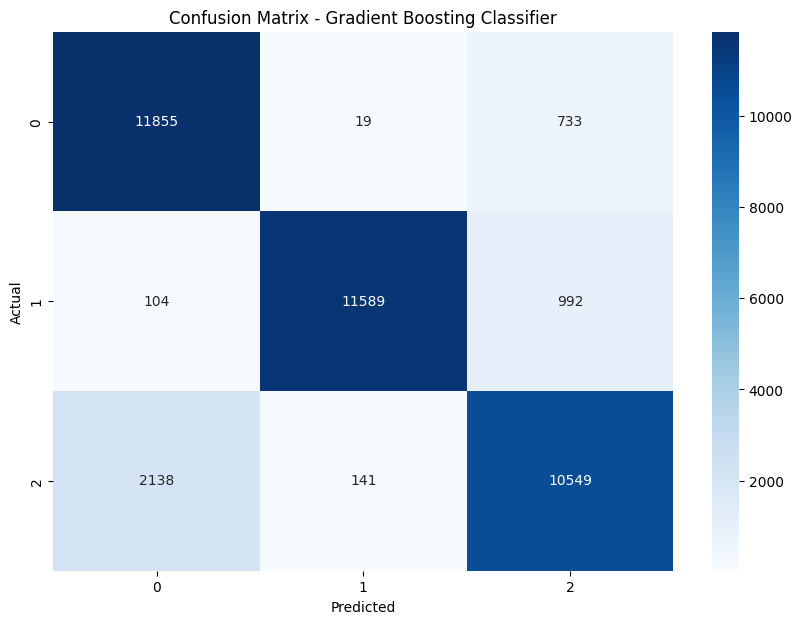

In [4]:
# preparing the data
X = df_safe_driving[['duration_seconds', 'speed_kmh', 'end_speed_kmh', 'maxwaarde', 'category_encoded']]  # Features
y = df_safe_driving['incident_severity_bin']

# splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# initializing StandardScaler
scaler = StandardScaler()

# Fitting scaler to training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Manually set the best parameters you assumed
best_params = {
    'n_estimators': 100, 
    'learning_rate': 0.1  
}

# Training the model with the best parameters
gbc_best = GradientBoostingClassifier(**best_params, random_state=42)
gbc_best.fit(X_train_scaled, y_train)

# Predictions
y_pred_best = gbc_best.predict(X_test_scaled)

# Evaluation of the model
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Accuracy: {accuracy_best:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best)
print(cm)

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Gradient Boosting Classifier')
plt.show()

Interpretation of the results: 

The model performs very well overall, with an accuracy of 89%.
The Low class has the highest precision (0.99) and F1-score (0.95), indicating that the model is very effective at predicting this class with few false positives and false negatives.
The High class also has a high recall (0.94), meaning the model is good at identifying most instances of this class, though its precision is slightly lower (0.85), indicating some false positives.
The Medium class has the lowest recall (0.83) and F1-score (0.84), suggesting that this class is the most challenging for the model to predict accurately, with more instances being misclassified compared to the other two classes.

### This is the ML model using Gradient Boosting with Grid Search 

This is the first model using Gradient Boosting with Gird Search so I can find the best parameters possible from this model. This model is built to predict the severity of incidents based on driving data given to us from the ANWB. The process includes the following steps in the following code below:

1. Preparing the Data: 
   The feature set X is created from specific columns of the df_safe_driving DataFrame, and the target variable y is set as the incident_severity_bin column.

2. Splitting the Data: 
   The data is split into training and testing sets using an 80-20 split.

3. Standardizing the Data: 
   A StandardScaler is used to standardize the feature values of both the training and testing sets.

4. Hyperparameter Tuning: 
   A GridSearchCV is initialized to perform hyperparameter tuning on the GradientBoostingClassifier. The parameter grid includes different values for n_estimators and learning_rate.

5. Training the Model: 
   The grid search is conducted to find the best hyperparameters, which are then used to train a GradientBoostingClassifier.

6. Making Predictions: 
   The trained model is used to make predictions on the test set.

7. Evaluating the Model: 
   The model's accuracy is calculated, and a classification report and confusion matrix are generated to evaluate the model's performance.

8. Visualizing the Results: 
   A heatmap of the confusion matrix is plotted using Seaborn to visualize the performance of the model.

Best parameters: {'learning_rate': 0.2, 'n_estimators': 200}
Accuracy: 0.89

Classification Report:
              precision    recall  f1-score   support

        High       0.85      0.94      0.89     12607
         Low       0.99      0.91      0.95     12685
      Medium       0.86      0.83      0.84     12828

    accuracy                           0.89     38120
   macro avg       0.90      0.89      0.89     38120
weighted avg       0.90      0.89      0.89     38120


Confusion Matrix:
[[11839     2   766]
 [  109 11570  1006]
 [ 2037   117 10674]]
[[11839     2   766]
 [  109 11570  1006]
 [ 2037   117 10674]]


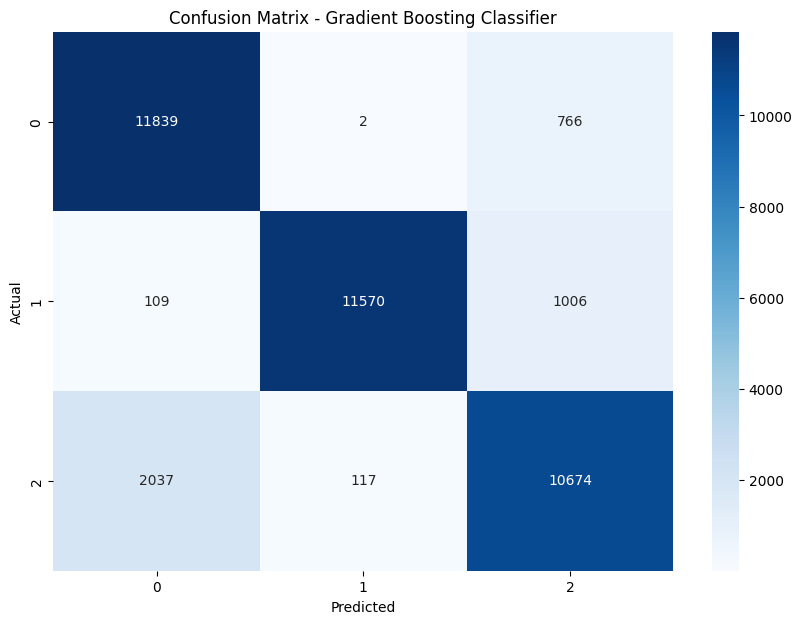

In [5]:
# parameter grid with the parameters that I assumed are best for training a ML model using Gradient Boosting 
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.05, 0.1, 0.2]
}

#im just saving here inn the chat this code: # Step 1: prepraring the data
X = df_safe_driving[['speed_kmh', 'end_speed_kmh', 'maxwaarde', 'category_encoded']]  # Features
y = df_safe_driving['incident_severity_bin']

# Step 2: splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# initializing StandardScaler
scaler = StandardScaler()

# Fitting scaler to training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# initializing the gridsearch
grid_search = GridSearchCV(estimator=GradientBoostingClassifier(random_state=42), param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# fitting gridsearch
grid_search.fit(X_train_scaled, y_train)

# best parameters from teh grid search
best_params = grid_search.best_params_
print(f"Best parameters: {best_params}")

# training the model with the best parameters
gbc_best = GradientBoostingClassifier(**best_params, random_state=42)
gbc_best.fit(X_train_scaled, y_train)

#predictions
y_pred_best = gbc_best.predict(X_test_scaled)

#evaluation of the model
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Accuracy: {accuracy_best:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best)
print(cm)

#plotting the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Gradient Boosting Classifier')
plt.show()

### Trying other models: Random Forest; XGBoost and Logistic Regression, so I can compare their general results such as accuracy 

In [6]:
#initializing the labelencoder
le = LabelEncoder()

#fit and transform the target variable
y_encoded = le.fit_transform(y)

# splitting agin the data with the encoded target variable
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

#scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#training and evaluating models
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.2f}")

# xgBoost
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy_xgb:.2f}")

#logistic regression
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_log_reg = log_reg.predict(X_test_scaled)
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
print(f"Logistic Regression Accuracy: {accuracy_log_reg:.2f}")


Random Forest Accuracy: 0.94
XGBoost Accuracy: 0.90
Logistic Regression Accuracy: 0.57


Apparently the best result gives the Random Forest which Spyros is developing more but I just wanted to check what result it would give to me.The idea of this code above is to compare the three models and if I can improve them. I will actually try below more iterations for XGBoost because it seems it would have good results. 

### Model 2 - XGBOOST

Now, I will try to train ML model using XGBoost Classifier bcause previously in the cell where I compared Logistic Regression, Random Forest and XGBoost this was the one classifier which gave the best results. 

Best parameters: {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 2, 'n_estimators': 100, 'subsample': 0.8}
Accuracy: 0.89

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89     12607
           1       0.99      0.91      0.95     12685
           2       0.86      0.82      0.84     12828

    accuracy                           0.89     38120
   macro avg       0.90      0.89      0.89     38120
weighted avg       0.90      0.89      0.89     38120


Confusion Matrix:
[[11930    11   666]
 [  100 11531  1054]
 [ 2169   117 10542]]
[[11930    11   666]
 [  100 11531  1054]
 [ 2169   117 10542]]


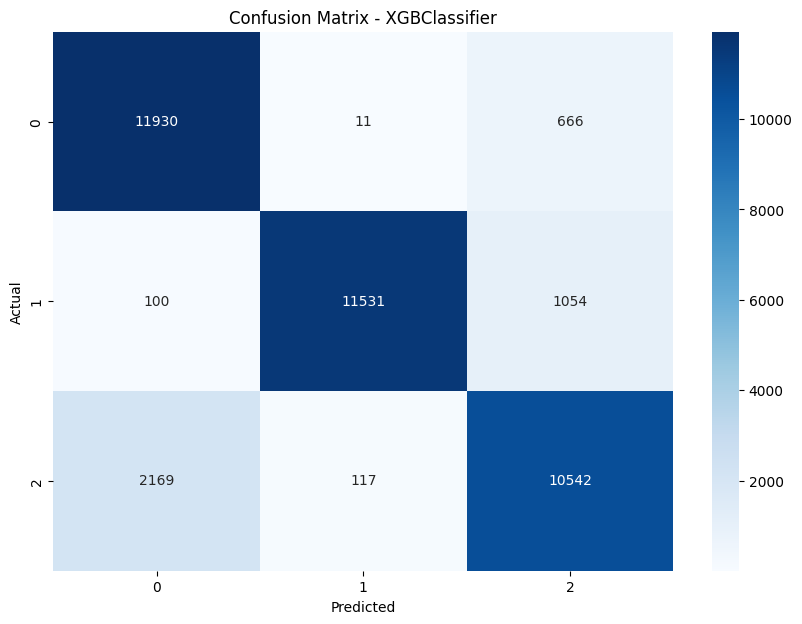

In [7]:
# Step 1:preprainhg the data
X = df_safe_driving[['duration_seconds', 'speed_kmh', 'end_speed_kmh', 'maxwaarde', 'category_encoded']]  # Features
y = df_safe_driving['incident_severity_bin']

# encoding the target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Step 2: splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# initializing the stadard scaler
scaler = StandardScaler()

# Fitting scaler to training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# defining the parameter grid
param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4],
    'min_child_weight': [1, 2],
    'gamma': [0, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# initializing the gridsearch
grid_search = GridSearchCV(estimator=XGBClassifier(random_state=42), param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

#fritting the gridserach 
grid_search.fit(X_train_scaled, y_train)

# best parameters
best_params = grid_search.best_params_
print(f"Best parameters: {best_params}")

# training the model with the best parameters
xgb_best = XGBClassifier(**best_params, random_state=42)
xgb_best.fit(X_train_scaled, y_train)

#predictions
y_pred_best = xgb_best.predict(X_test_scaled)

# evaluation of the model
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Accuracy: {accuracy_best:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best)
print(cm)

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBClassifier')
plt.show()

### Advanced Feature Engineering on the Xboost for IMPROVEMENT 

Accuracy with Polynomial Features: 0.92

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.98      0.92     12607
           1       0.99      0.92      0.95     12685
           2       0.90      0.86      0.88     12828

    accuracy                           0.92     38120
   macro avg       0.92      0.92      0.92     38120
weighted avg       0.92      0.92      0.92     38120


Confusion Matrix:
[[12315     2   290]
 [   77 11674   934]
 [ 1665   103 11060]]
[[11930    11   666]
 [  100 11531  1054]
 [ 2169   117 10542]]


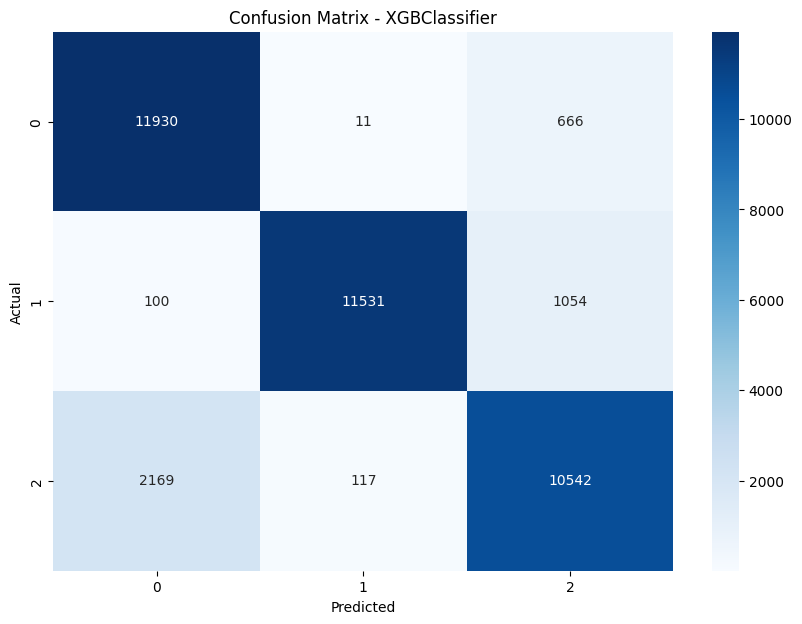

In [8]:
# adding polynomial features
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# reatrining with polynomial features
xgb_poly = XGBClassifier(random_state=42)
xgb_poly.fit(X_train_poly, y_train)

# predictions
y_pred_poly = xgb_poly.predict(X_test_poly)

# evaluation of the model
accuracy_poly = accuracy_score(y_test, y_pred_poly)
print(f"Accuracy with Polynomial Features: {accuracy_poly:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_poly))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_poly))

cm = confusion_matrix(y_test, y_pred_best)
print(cm)

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBClassifier')
plt.show()

Combining models Random Forest and XGBoosting and Gradient Boosting 

Voting Classifier Accuracy: 0.93

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     12607
           1       0.99      0.92      0.96     12685
           2       0.92      0.88      0.90     12828

    accuracy                           0.93     38120
   macro avg       0.93      0.93      0.93     38120
weighted avg       0.93      0.93      0.93     38120


Confusion Matrix:
[[12508     0    99]
 [   74 11704   907]
 [ 1436    83 11309]]
[[11930    11   666]
 [  100 11531  1054]
 [ 2169   117 10542]]


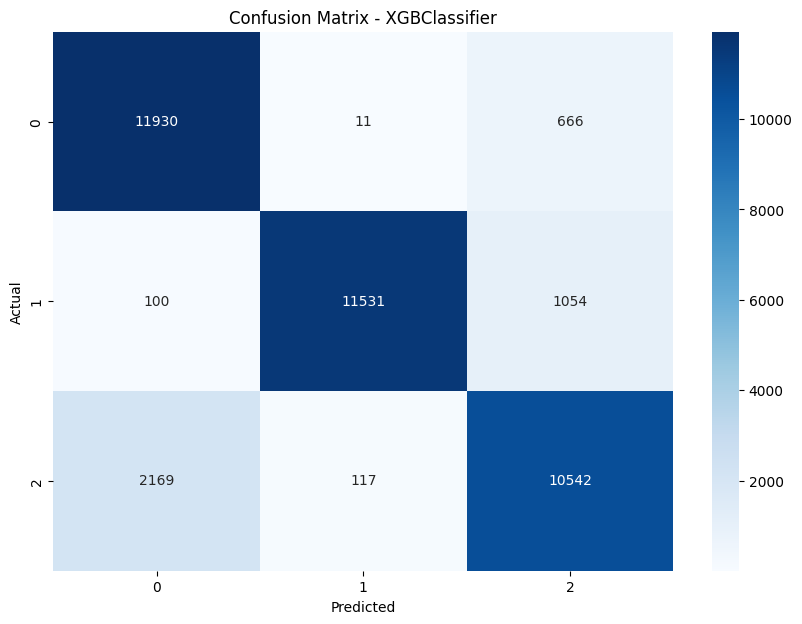

In [9]:
from sklearn.ensemble import VotingClassifier
import seaborn as sns 

# Define individual models
model1 = RandomForestClassifier(random_state=42)
model2 = XGBClassifier(random_state=42)
model3 = GradientBoostingClassifier(random_state=42)

# combining models in a voting classifier
voting_clf = VotingClassifier(estimators=[
    ('rf', model1), 
    ('xgb', model2), 
    ('gbc', model3)
], voting='soft')

#training the voting classifier
voting_clf.fit(X_train_scaled, y_train)

# predictions
y_pred_voting = voting_clf.predict(X_test_scaled)

# evaluation of the model
accuracy_voting = accuracy_score(y_test, y_pred_voting)
print(f"Voting Classifier Accuracy: {accuracy_voting:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_voting))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_voting))

cm = confusion_matrix(y_test, y_pred_best)
print(cm)

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBClassifier')
plt.show()

No will plot the feature importance for the XGBoost Classifier

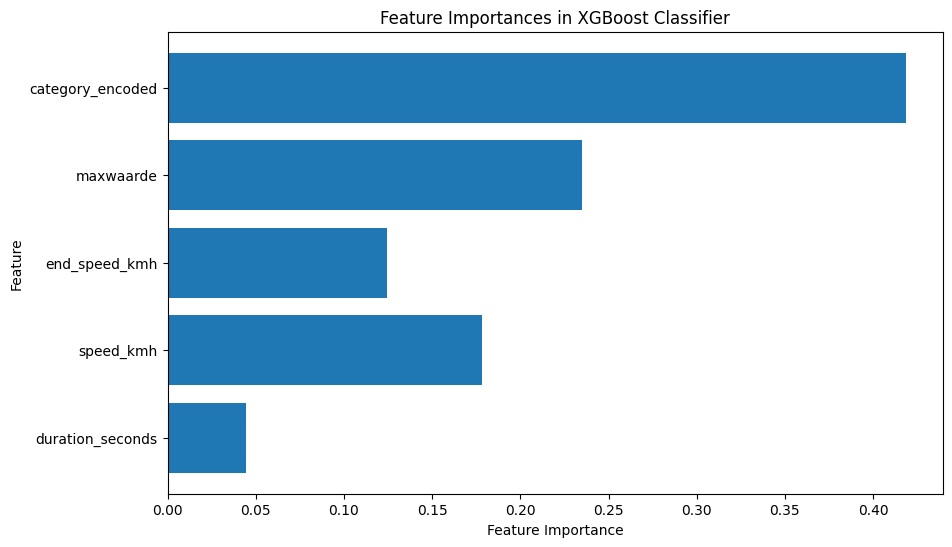

In [10]:
import matplotlib.pyplot as plt

# training the model
xgb_best.fit(X_train_scaled, y_train)

#feature importances plot
plt.figure(figsize=(10, 6))
plt.barh(X.columns, xgb_best.feature_importances_)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importances in XGBoost Classifier')
plt.show()
